---
title: "Dow Jones"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Dow Jones Industrial Average (monthly)
- **description:** Monthly closing values of the Dow Jones Industrial Average from December 1914 through December 1968.
- **provenance:** NBER Macrohistory Database via FRED (series `M1109BUSM293NNBR`); monthly DJIA close originally compiled by Dow Jones & Co.
- **format:** long / tidy time series — 649 rows x 2 columns.

**Data dictionary**

- `Date` — *(identifier)* month of observation, as a datetime (first of the month).
- `Price` — *(measurement)* closing value of the index that month.

**Structure**

- **Rows:** 649 — one row per month.
- **Columns:** 2.
- **Identifiers:** `Date`.
- **Measurements:** `Price`.

**Use cases**

- line charts of long-run trends
- resampling / aggregation by year
- bar charts of annual means


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form (tidy)

In [27]:
dowjones = sns.load_dataset('dowjones')
dowjones

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45
...,...,...
644,1968-08-01,883.72
645,1968-09-01,922.80
646,1968-10-01,955.47
647,1968-11-01,964.12


### Long form with key index

In [28]:
dowjones2 = dowjones.copy()
dowjones2['Date'] = pd.to_datetime(dowjones.Date)
dowjones2 = dowjones2.set_index('Date')
dowjones2

,Price
Date,
1914-12-01,55.00
1915-01-01,56.55
1915-02-01,56.00
1915-03-01,58.30
1915-04-01,66.45
...,...
1968-08-01,883.72
1968-09-01,922.80
1968-10-01,955.47


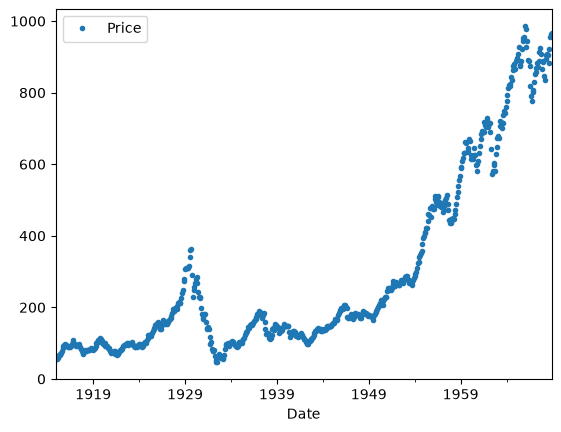

In [30]:
dowjones2.plot(style='.')
plt.show()

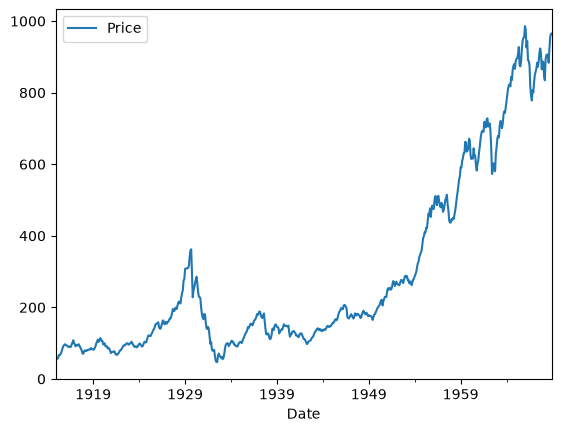

In [32]:
dowjones2.plot()
plt.show()

### Long form aggregated by year

In [33]:
dowjones3 = dowjones.groupby(dowjones2.index.year).Price.mean().to_frame('mean_price')
dowjones3.head()

,mean_price
Date,
1914,55.000000
1915,74.329167
1916,94.791667
1917,87.729167
1918,81.066667


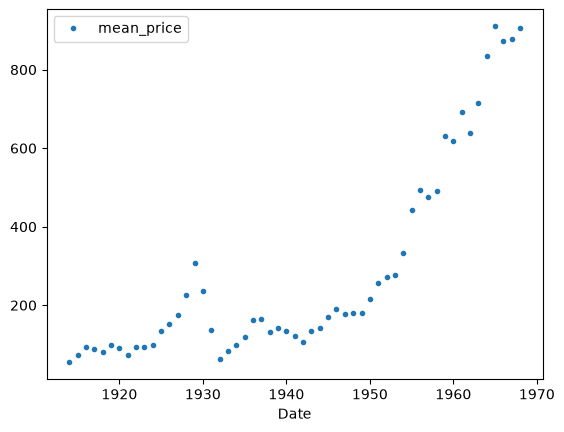

In [45]:
dowjones3.plot(style='.')
plt.show()

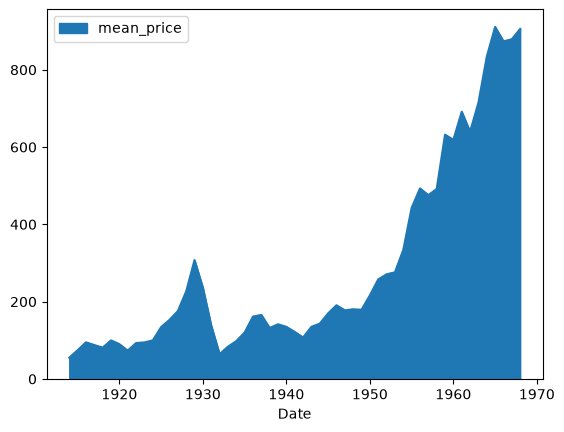

In [43]:
dowjones3.plot.area()
plt.show()

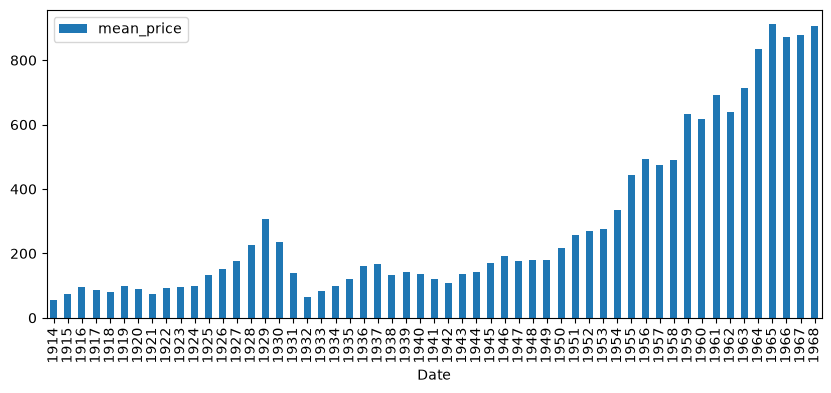

In [6]:
dowjones3.plot.bar(figsize=(10,4))
plt.show()

### Wide form aggregated by year and month

In [26]:
dowjones3 = dowjones.groupby([dowjones.Date.dt.year, dowjones.Date.dt.month]).Price.mean().to_frame('mean_price').unstack()
dowjones3.style.format(precision=2).background_gradient(axis=0)